In [2]:
import xarray as xr
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
import re
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.pyplot as plt
import regionmask


In [39]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [40]:
#Regridded ERA5 31km
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
regridded_era5 = regridded_era5.where(oceanmask != 17)


In [4]:
geo

<xarray.Dataset> Size: 102MB
Dimensions:     (Time: 1, south_north: 450, west_east: 420,
                 south_north_stag: 451, west_east_stag: 421, land_cat: 21,
                 soil_cat: 16, month: 12)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month
Data variables: (12/53)
    Times       (Time) |S19 19B ...
    XLAT_M      (Time, south_north, west_east) float32 756kB ...
    XLONG_M     (Time, south_north, west_east) float32 756kB ...
    XLAT_V      (Time, south_north_stag, west_east) float32 758kB ...
    XLONG_V     (Time, south_north_stag, west_east) float32 758kB ...
    XLAT_U      (Time, south_north, west_east_stag) float32 758kB ...
    ...          ...
    OL1         (Time, south_north, west_east) float32 756kB ...
    OL2         (Time, south_north, west_east) float32 756kB ...
    OL3         (Time, south_north, west_east) float32 756kB ...
    OL4         (Time, south_north, west_east) float32 756kB ...
    VAR_SSO     (Time, south_north, west_east) float32 756kB ...
    LAKE_DEPTH  (Time, south_north, west_east) float32 756kB ...
Attributes: (12/48)
    TITLE:                           OUTPUT FROM GEOGRID V4.5
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        421
    SOUTH-NORTH_GRID_DIMENSION:      451
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    sr_x:                            1
    sr_y:                            1
    FLAG_MF_XY:                      1
    FLAG_LAI12M:                     1
    FLAG_VAR_SSO:                    1
    FLAG_LAKE_DEPTH:                 1

In [41]:
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

monthlist=['November','December','January','February','March' ]
monthnumberlist=[11,12,1,2,3]

In [42]:
ros_seasonal_total_4km=era5_4km['ros_tally'].sum(axis=1)
ros_seasonal_total_31km=regridded_era5['ros_tally'].sum(axis=1)
#ros_rain_sum_season_total_SUM_4km=era5_4km['rain_ros_sum'].sum(axis=1).mean(axis=0)

In [43]:
def compute_ros_hours_normalized(data):
    """Compute total ROS hours per season, number of pixels with ROS per season,
    and normalized ROS hours (total / number of pixels)
    
    seasons : season labels
    ros_hourly_totals_climatology  Total ROS hours per season
    n_pixels_per_season : Number of pixels with ROS per season
    ros_hours_normalized : Normalized ROS hours per season"""

    ros_hourly_totals_climatology = []
    n_pixels_per_season = []

    for i in range(len(data.season)):
        ros_this_season = data.isel(season=i)
        # Total ROS hours
        total = ros_this_season.sum().compute().item()
        ros_hourly_totals_climatology.append(total)
        # Count pixels with ROS (> 0)
        grid_with_ros = ros_this_season > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_season.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]

    seasons = [str(s) for s in data.season.values]

    return seasons, ros_hourly_totals_climatology, n_pixels_per_season, ros_hours_normalized

In [44]:
seasons, totals_4s, n_pixels_4s, statewide_4km_normalized = compute_ros_hours_normalized(ros_seasonal_total_4km)

seasons, totals_31s, n_pixels_31s, statewide_31km_normalized = compute_ros_hours_normalized(ros_seasonal_total_31km)

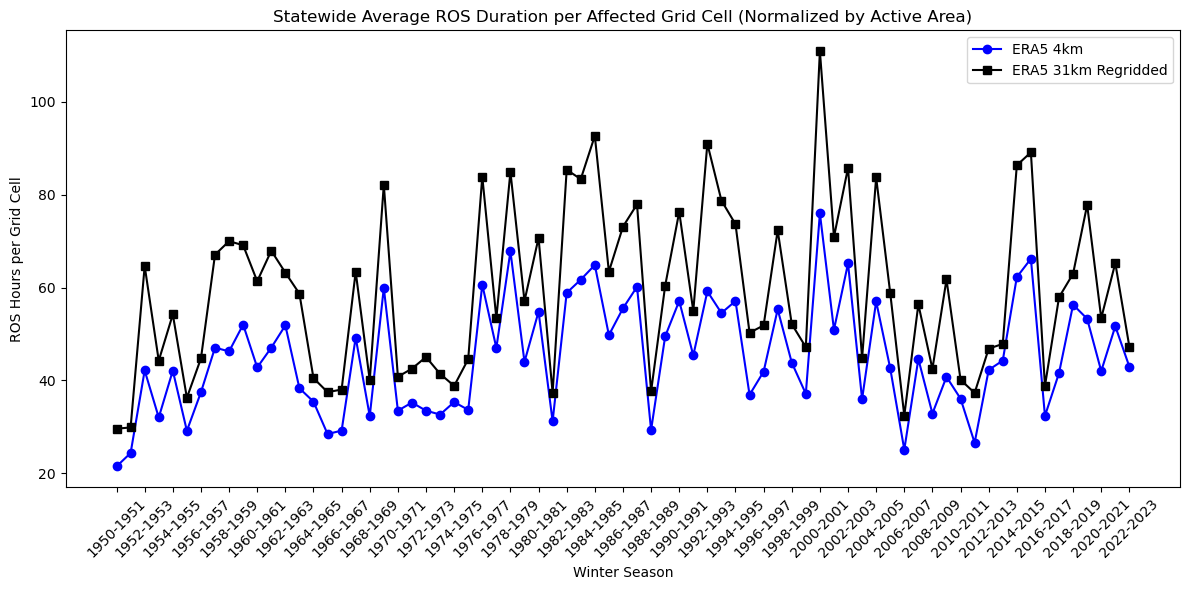

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(seasons, statewide_4km_normalized, marker='o', linestyle='-', color='blue',label='ERA5 4km')
plt.plot(seasons, statewide_31km_normalized, marker='s', linestyle='-', color='black',label='ERA5 31km Regridded')
plt.title('Statewide Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

In [46]:
def borough_land_mask(shapefile,data,lat,lon):
    mask = regionmask.mask_geopandas(shapefile, lon, lat)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [47]:
anc_only_ros_4km = borough_land_mask(Mun_of_Anc_boundary, ros_seasonal_total_4km, lat, lon)
anc_only_ros_31km = borough_land_mask(Mun_of_Anc_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4anc, totals_4s_anc, n_pixels_4s_anc, anc_4km_normalized = compute_ros_hours_normalized(anc_only_ros_4km)
seasons_31anc, totals_31s_anc, n_pixels_31s_anc, anc_31km_normalized = compute_ros_hours_normalized(anc_only_ros_31km)

fai_only_ros_4km = borough_land_mask(FNSB_boundary, ros_seasonal_total_4km, lat, lon)
fai_only_ros_31km = borough_land_mask(FNSB_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4fai, totals_4s_fai, n_pixels_4s_fai, fai_4km_normalized = compute_ros_hours_normalized(fai_only_ros_4km)
seasons_31fai, totals_31s_fai, n_pixels_31s_fai, fai_31km_normalized = compute_ros_hours_normalized(fai_only_ros_31km)

bet_only_ros_4km = borough_land_mask(Bethel_boundary, ros_seasonal_total_4km, lat, lon)
bet_only_ros_31km = borough_land_mask(Bethel_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4bet, totals_4s_bet, n_pixels_4s_bet, bet_4km_normalized = compute_ros_hours_normalized(bet_only_ros_4km)
seasons_31bet, totals_31s_bet, n_pixels_31s_bet, bet_31km_normalized = compute_ros_hours_normalized(bet_only_ros_31km)


In [48]:
#ros_seasonal_total_4km
#ros_seasonal_total_31km

In [49]:
start_years = np.array([int(s.split('-')[0]) for s in seasons])
decades_assigned = (start_years // 10) * 10

In [50]:
statewide_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": statewide_4km_normalized
})
statewide_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": statewide_31km_normalized})

decadal_means_4km = statewide_4km_decadal_df.groupby("decade")["normalized"].mean()
decadal_means_31km = statewide_31km_decadal_df.groupby("decade")["normalized"].mean()



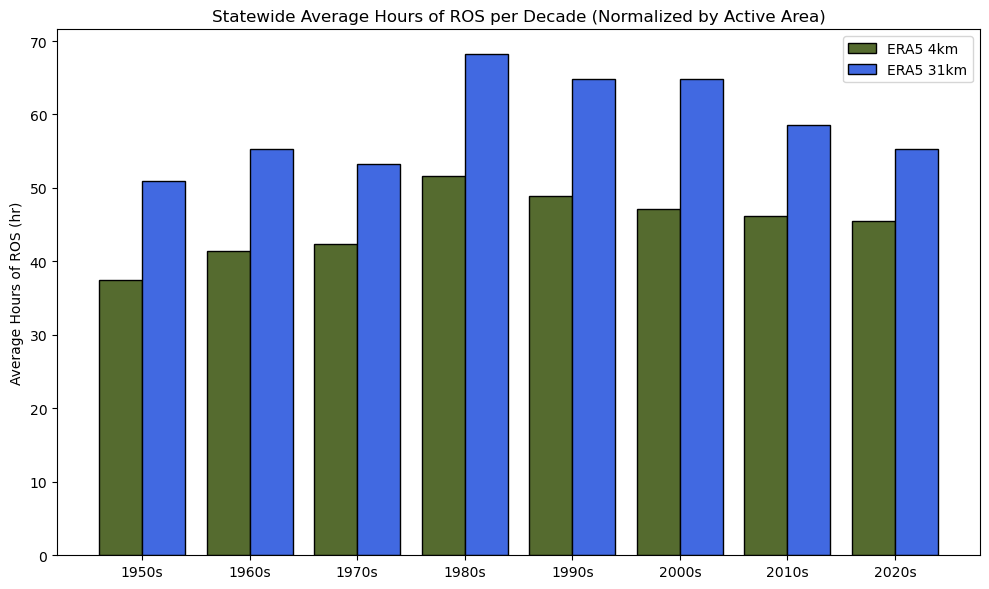

In [51]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

x = np.arange(len(decades))
width = 0.40
fig, ax = plt.subplots(figsize=(10,6))


ax.bar(x - 0.5*width, decadal_means_4km, width, color='darkolivegreen', edgecolor='black', label='ERA5 4km')
ax.bar(x + 0.5*width, decadal_means_31km, width, color='royalblue', edgecolor='black', label='ERA5 31km')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')

ax.set_title('Statewide Average Hours of ROS per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
anc_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": anc_4km_normalized
})
anc_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": anc_31km_normalized})

anc_decadal_means_4km = anc_4km_decadal_df.groupby("decade")["normalized"].mean()
anc_decadal_means_31km = anc_31km_decadal_df.groupby("decade")["normalized"].mean()

fai_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": fai_4km_normalized
})
fai_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": fai_31km_normalized})

fai_decadal_means_4km = fai_4km_decadal_df.groupby("decade")["normalized"].mean()
fai_decadal_means_31km = fai_31km_decadal_df.groupby("decade")["normalized"].mean()

In [53]:
bet_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": bet_4km_normalized
        })


bet_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": bet_31km_normalized})

bet_decadal_means_4km = bet_4km_decadal_df.groupby("decade")["normalized"].mean()
bet_decadal_means_31km = bet_31km_decadal_df.groupby("decade")["normalized"].mean()


In [54]:
borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

average_colors = {
    "Anchorage": "#63a8b7",
    "Fairbanks": "#c37234",
    "Bethel": "#7673a2",
    "Statewide": "#005fa5"
}

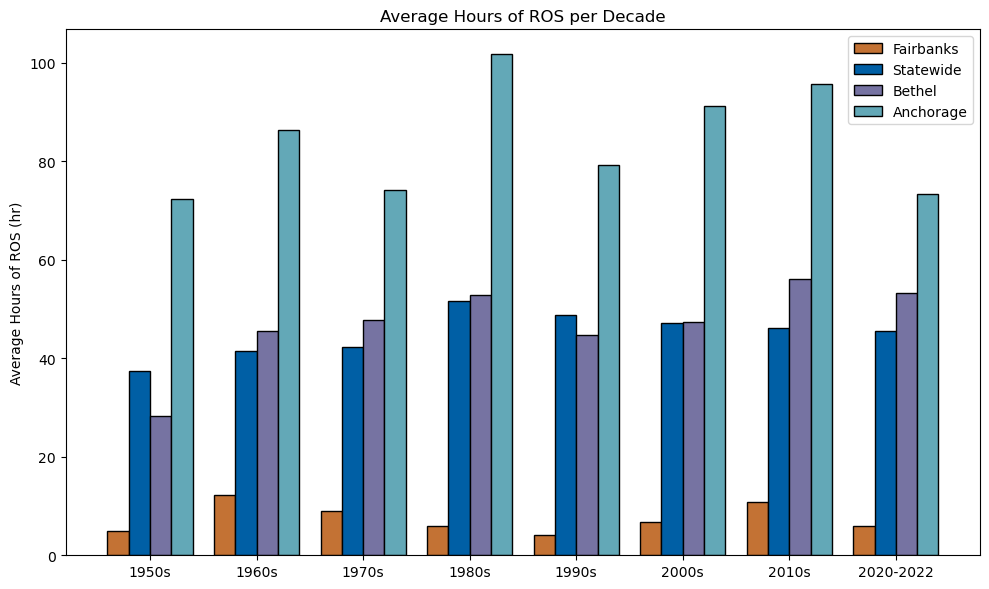

In [55]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020-2022']


x = np.arange(len(decades))
width = 0.20
fig, ax = plt.subplots(figsize=(10,6))
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

ax.bar(x - 1.5*width, fai_decadal_means_4km, width, color=average_colors[1], edgecolor='black', label='Fairbanks')
ax.bar(x - .5*width, decadal_means_4km, width, color=average_colors[3], edgecolor='black', label='Statewide')
ax.bar(x + 0.5*width, bet_decadal_means_4km, width, color=average_colors[2], edgecolor='black', label='Bethel')
ax.bar(x + 1.5*width, anc_decadal_means_4km, width, color=average_colors[0], edgecolor='black', label='Anchorage')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')

ax.set_title('Average Hours of ROS per Decade')
ax.legend()
plt.tight_layout()
plt.show()

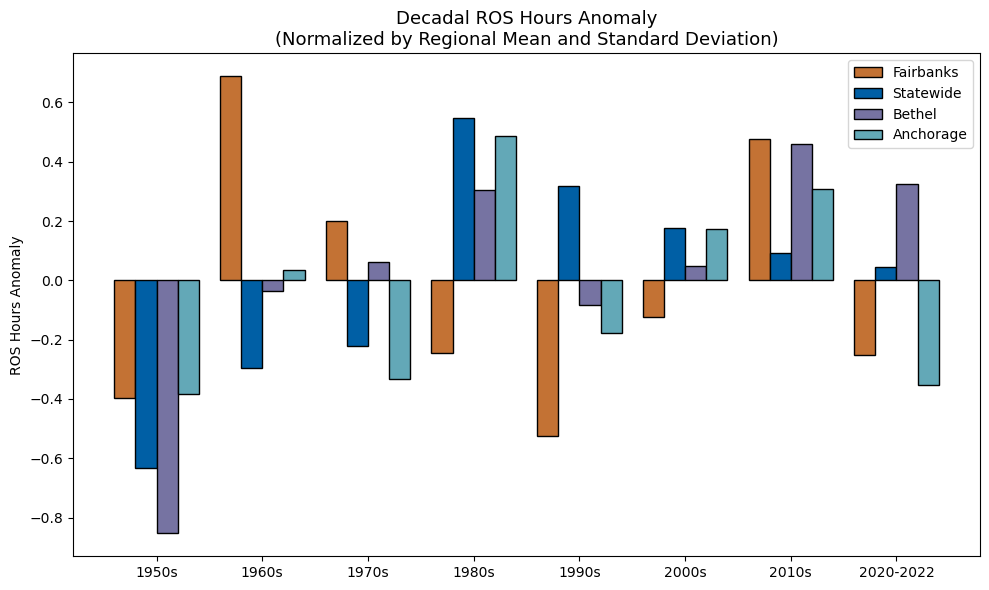

In [56]:
fai_avg=np.mean(fai_4km_normalized)
statewide_avg=np.mean(statewide_4km_normalized)
bet_avg=np.mean(bet_4km_normalized)
anc_avg=np.mean(anc_4km_normalized)


fai_decadal_means_normalized = (fai_decadal_means_4km - fai_avg) / np.std(fai_4km_normalized)
statewide_decadal_means_normalized = (decadal_means_4km - statewide_avg) / np.std(statewide_4km_normalized)
bet_decadal_means_normalized = (bet_decadal_means_4km - bet_avg) / np.std(bet_4km_normalized)
anc_decadal_means_normalized = (anc_decadal_means_4km - anc_avg) / np.std(anc_4km_normalized)


decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020-2022']


x = np.arange(len(decades))
width = 0.20
fig, ax = plt.subplots(figsize=(10,6))
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

ax.bar(x - 1.5*width, fai_decadal_means_normalized, width, color=average_colors[1], edgecolor='black', label='Fairbanks')
ax.bar(x - .5*width, statewide_decadal_means_normalized, width, color=average_colors[3], edgecolor='black', label='Statewide')
ax.bar(x + 0.5*width, bet_decadal_means_normalized, width, color=average_colors[2], edgecolor='black', label='Bethel')
ax.bar(x + 1.5*width, anc_decadal_means_normalized, width, color=average_colors[0], edgecolor='black', label='Anchorage')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('ROS Hours Anomaly')

ax.set_title('Decadal ROS Hours Anomaly\n(Normalized by Regional Mean and Standard Deviation)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

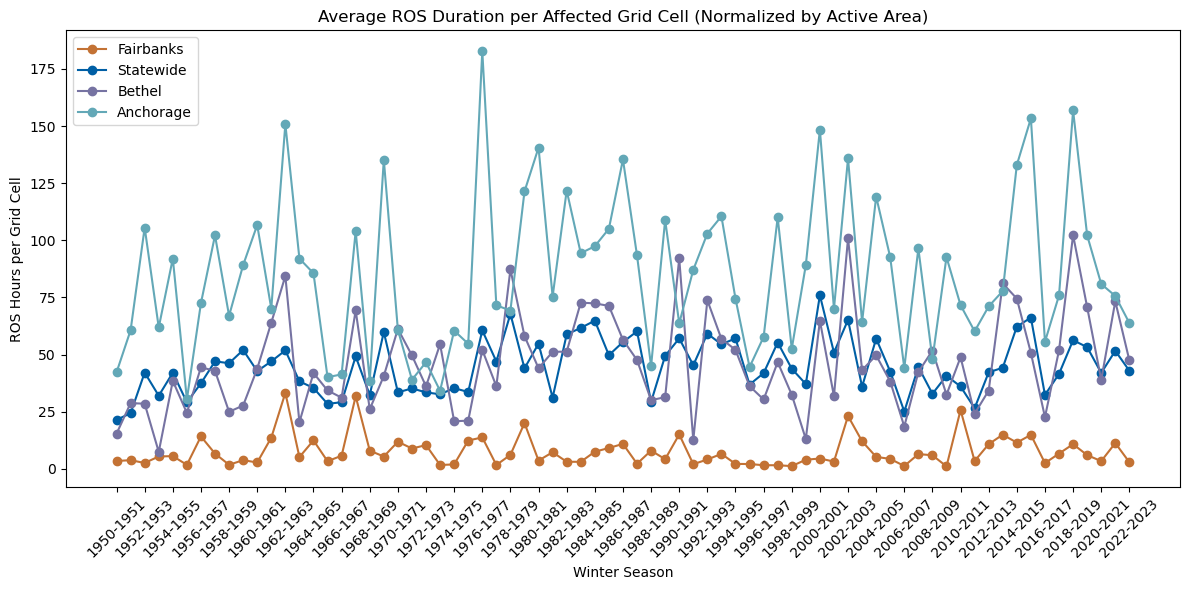

In [57]:
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

plt.figure(figsize=(12, 6))

plt.plot(seasons_4anc, fai_4km_normalized, marker='o', linestyle='-', color=average_colors[1],label='Fairbanks')
plt.plot(seasons_4anc, statewide_4km_normalized, marker='o', linestyle='-', color=average_colors[3],label='Statewide')
plt.plot(seasons_4anc, bet_4km_normalized, marker='o', linestyle='-', color=average_colors[2],label='Bethel')
plt.plot(seasons_4anc, anc_4km_normalized, marker='o', linestyle='-', color=average_colors[0],label='Anchorage')
plt.title('Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

RAIN
-

In [58]:
def compute_ros_rainfall_sum(data):
    ros_rainsum_totals_climatology = []
    
    for i in range(len(data.season)):
        ros_this_season = data.isel(season=i)
        # Total ROS hours
        total = ros_this_season.sum().compute().item()
        ros_rainsum_totals_climatology.append(total)
    seasons = [str(s) for s in data.season.values]

    return seasons, ros_rainsum_totals_climatology 

decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020-2022']


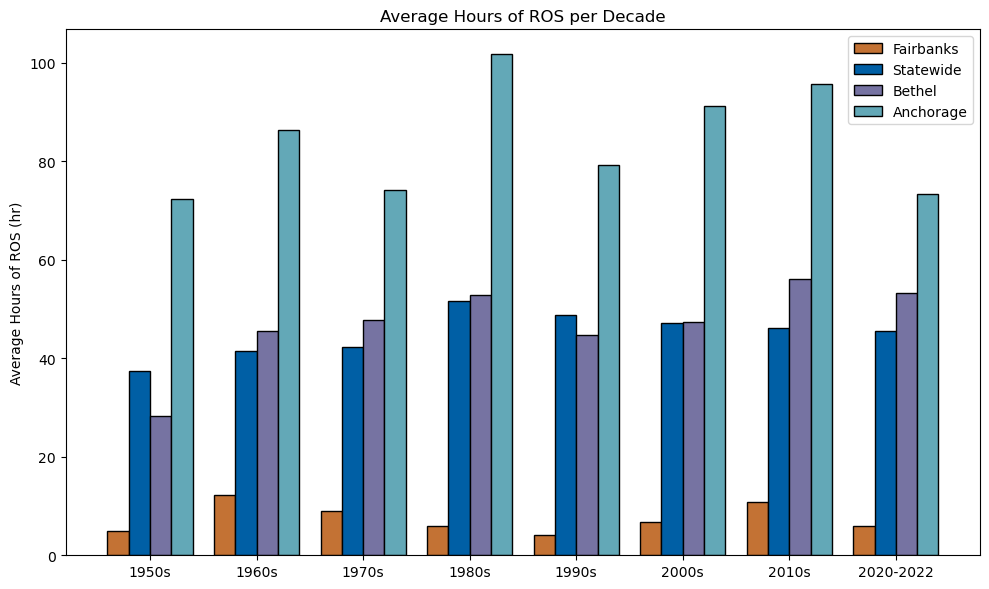

In [59]:
x = np.arange(len(decades))
width = 0.20
fig, ax = plt.subplots(figsize=(10,6))
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

ax.bar(x - 1.5*width, fai_decadal_means_4km, width, color=average_colors[1], edgecolor='black', label='Fairbanks')
ax.bar(x - .5*width, decadal_means_4km, width, color=average_colors[3], edgecolor='black', label='Statewide')
ax.bar(x + 0.5*width, bet_decadal_means_4km, width, color=average_colors[2], edgecolor='black', label='Bethel')
ax.bar(x + 1.5*width, anc_decadal_means_4km, width, color=average_colors[0], edgecolor='black', label='Anchorage')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')

ax.set_title('Average Hours of ROS per Decade')
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
import requests
import io
import pandas as pd

url = "https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/v6/index/ersst.v6.pdo.dat"

r = requests.get(url)
data = io.StringIO(r.text)

df = pd.read_fwf(
    data,
    skiprows=1   # skip "ERSST PDO Index:"
)

print(df.head())
print(df.columns)

   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1850  1.06 -0.95 -1.77 -2.77 -1.28 -1.46 -0.22  1.10  0.13 -2.41 -1.17   
1  1851 -0.66  0.73  0.44 -0.45 -0.60 -0.39 -0.17 -0.30  0.37  2.08  1.49   
2  1852 -0.37 -0.38 -1.30  0.50  1.18  1.28  2.23  2.61  0.30  2.51  0.19   
3  1853  0.17 -1.71  2.69  0.87 -0.86 -0.71 -1.70  0.22 -0.12  0.90  0.32   
4  1854 -0.13 -1.81  0.16  0.52 -0.77 -1.43  1.29  1.46 -0.81 -0.54  0.07   

    Dec  
0  2.74  
1  0.86  
2 -2.21  
3 -0.97  
4  1.10  
Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'],
      dtype='object')


In [33]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df[df["Year"] > 1949]
df = df[df["Year"] < 2023]

In [72]:
month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df["PDO_year"] = df[month_cols].mean(axis=1)
decades = np.array([int(d[:4]) for d in decades])

In [38]:
PDO = df[["Year", "PDO_year"]]
PDO

,Year,PDO_year
100,1950,-1.681667
101,1951,-0.619167
102,1952,-0.953333
103,1953,-0.237500
104,1954,0.000833
...,...,...
168,2018,-0.192500
169,2019,0.104167
170,2020,-0.938333
171,2021,-1.809167


In [73]:
PDO["Decade"] = (PDO["Year"] // 10) * 10
pdo_decadal.index = pdo_decadal.index.astype(int)

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1735843/3525588426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PDO["Decade"] = (PDO["Year"] // 10) * 10


In [ ]:
'''decadal_means_4km
fai_decadal_means_4km
bet_decadal_means_4km
anc_decadal_means_4km'''

In [76]:
common_decades = np.intersect1d(decades, pdo_decadal.index)
ros_df = pd.DataFrame({
    "Decade": np.array([int(d[:4]) if isinstance(d, str) else d for d in decades]),
    "ROS": decadal_means_4km
})
pdo_df = pdo_decadal.reset_index()
pdo_df.columns = ["Decade", "PDO"]

merged = pd.merge(ros_df, pdo_df, on="Decade", how="inner").dropna()

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(merged["ROS"], merged["PDO"])
print(r, p)

0.40222312730559906 0.32322503698985167


In [83]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

def corr(ros_series, decades, pdo_df):
    
    ros_df = pd.DataFrame({
        "Decade": np.array(decades, dtype=int),
        "ROS": ros_series
    })

    merged = pd.merge(ros_df, pdo_df, on="Decade", how="inner").dropna()

    if len(merged) < 2:
        return np.nan  # avoids your previous crash

    r, p = pearsonr(merged["ROS"], merged["PDO"])
    return r

print("Fairbanks:", corr(fai_decadal_means_4km, decades, pdo_df))
print("Statewide:", corr(decadal_means_4km, decades, pdo_df))
print("Bethel:", corr(bet_decadal_means_4km, decades, pdo_df))
print("Anchorage:", corr(anc_decadal_means_4km, decades, pdo_df))

Fairbanks: 0.02291381924789794
Statewide: 0.40222312730559906
Bethel: -0.001921947055934875
Anchorage: 0.6037668898612152


[Text(0, 0, '1950'),
 Text(1, 0, '1960'),
 Text(2, 0, '1970'),
 Text(3, 0, '1980'),
 Text(4, 0, '1990'),
 Text(5, 0, '2000'),
 Text(6, 0, '2010'),
 Text(7, 0, '2020')]

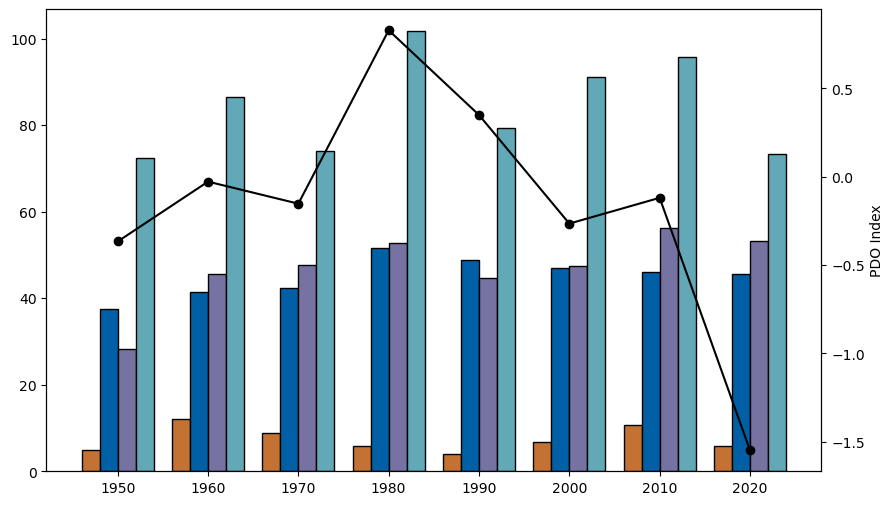

In [85]:
x = np.arange(len(decades))
width = 0.20

fig, ax = plt.subplots(figsize=(10,6))
colors = ["#c37234", "#005fa5", "#7673a2", "#63a8b7"]

ax.bar(x - 1.5*width, fai_decadal_means_4km, width,
       color=colors[0], edgecolor='black', label='Fairbanks')

ax.bar(x - 0.5*width, decadal_means_4km, width,
       color=colors[1], edgecolor='black', label='Statewide')

ax.bar(x + 0.5*width, bet_decadal_means_4km, width,
       color=colors[2], edgecolor='black', label='Bethel')

ax.bar(x + 1.5*width, anc_decadal_means_4km, width,
       color=colors[3], edgecolor='black', label='Anchorage')

ax2 = ax.twinx()
ax2.plot(x, merged['PDO'].values, color="black", marker="o", label="PDO")
ax2.set_ylabel("PDO Index")

ax.set_xticks(x)
ax.set_xticklabels(decades)